# Active Fire Detection using MTG FCI: Inference Pipeline

This notebook provides a complete workflow for applying pre-trained Machine Learning (CatBoost) and Deep Learning (MAnet) models to Meteosat Third Generation (MTG) Flexible Combined Imager (FCI) data. The pipeline handles data loading, model instantiation, and inference.

In [6]:
import sys
import os
sys.path.append(f"{os.getcwd()}/utils") ## add the utils folder to the path to import the MTG_toolbox module
import MTG_toolbox as MTGT
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from rasterio.plot import show
import rioxarray

## 1. Environment Setup and Data Paths

The following configuration defines the file paths for the input satellite data, the pre-trained model weights, and the designated output directories for the resulting predictions. The input data includes the 1km 4-band multispectral composite and the corresponding MTG Cloud Mask (CLM).

In [3]:
cloud_product_path = Path(r"Data\cloud\2025_07_24_10_50\2025_07_24_10_50.tif").as_posix() ## get the path of the cloud mask image
multispectral_product_path = Path(r"Data\multispectral\2025_07_24_10_50\2025_07_24_10_50.tif").as_posix() ## get the path of the multispectral image
DL_model_path = Path(r"models\DL\MAnet\DL_model.pth").as_posix() ## get the path of the DL model
ML_model_path = Path(r"models\ML\CatBoost\CatBoost.pkl").as_posix() ## get the path of the ML model
output_path_ML = Path(r"results\ML").as_posix() ## get the path to save the ML predicted image
output_path_DL = Path(r"results\DL").as_posix() ## get the path to save the DL predicted image
MTG_date_time = "2025-07-24 10:50" ## set the MTG date time

## 2. Data Loading and Band Visualization

The following section initiates the data pipeline by loading the multispectral MTG FCI image utilizing the `rioxarray` library. We visualize the third channel the 3.8 μm wavelength band, representing the Brightness Temperature (BT) which is a critical feature for active fire detection.

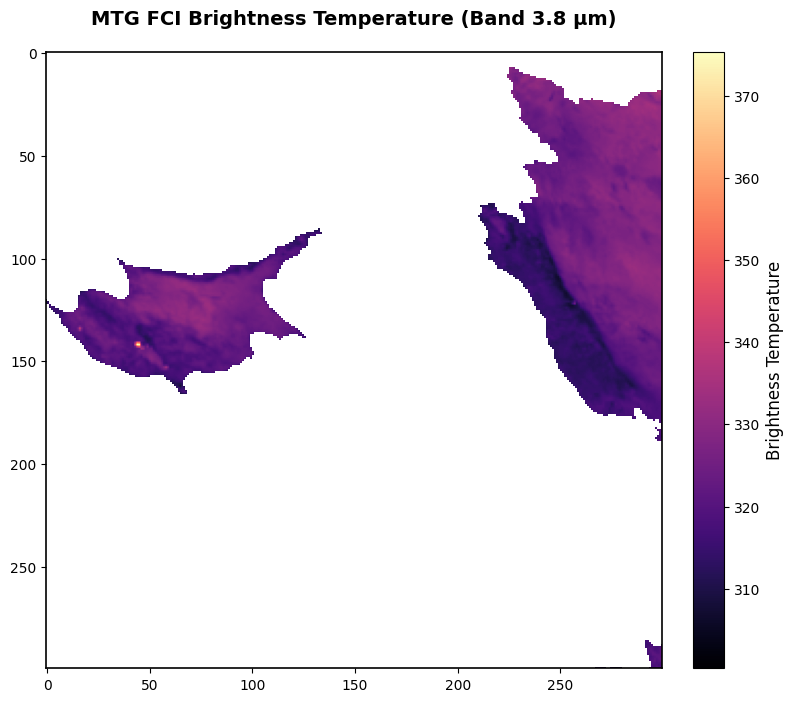

In [7]:
cyprus = rioxarray.open_rasterio(multispectral_product_path) ## open the multispectral image using rioxarray

fig, ax = plt.subplots(figsize=(10, 8))

## Show the multispectral image using rasterio with the magma colormap
show(cyprus[2], ax=ax, cmap='magma') 

## Ensure plot aesthetics: remove grid lines and apply distinct bounding frame
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

## Add title outside the image using the pad parameter
ax.set_title("MTG FCI Brightness Temperature (Band 3.8 μm)", pad=20, fontsize=14, fontweight='bold')

## Add a legend for the continuous values (colorbar)
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Brightness Temperature", fontsize=12)

plt.show()

## 3. Machine Learning Inference Visualization

This section visualizes the spatial distribution of the active fire predictions generated by the Machine Learning model.

In [8]:
ML_image = MTGT.predict_fire_using_ML(multispectral_path = multispectral_product_path, 
                                      CLM_path = cloud_product_path, 
                                      MTG_date_time = MTG_date_time, 
                                      ML_model_path = ML_model_path, 
                                      save_predicted_image = True, 
                                      save_predicted_image_path = output_path_ML)

Now working of MTG time stamp: 2025-07-24 10:50
Now working of MTG time stamp: 2025-07-24 10:50
MTG pixel list is done for MTG time stamp: 2025-07-24 10:50
staring to genrate fire pixel values for MTG time stamp: 2025-07-24 10:50
Starting to get the fire pixel values for MTG time stamp: 2025-07-24 10:50
done. df is ready for MTG time stamp: 2025-07-24 10:50
Predicted image saved to results/ML


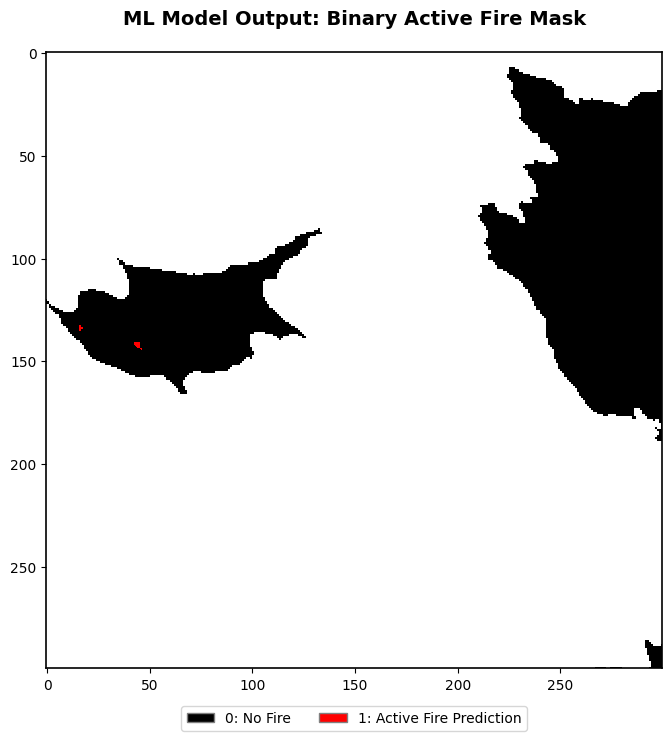

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

## Create a custom discrete colormap for binary data (0: Black, 1: Red)
custom_cmap = ListedColormap(['black', 'red'])

## Show the binary predicted fire pixels using the custom colormap
im = ax.imshow(ML_image[0], cmap=custom_cmap, vmin=0, vmax=1)

## Ensure plot aesthetics: remove grid lines and apply distinct bounding frame
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

## Add title outside the image using the pad parameter
ax.set_title("ML Model Output: Binary Active Fire Mask", pad=20, fontsize=14, fontweight='bold')

## Create legend patches matching the custom colormap exactly
legend_labels = [
    mpatches.Patch(facecolor='black', edgecolor='gray', linewidth=1, label='0: No Fire'),
    mpatches.Patch(facecolor='red', edgecolor='gray', linewidth=1, label='1: Active Fire Prediction')
]

## Place the legend below the plot, centered, spreading across 2 columns
ax.legend(handles=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.show()

## 4. Deep Learning Inference Visualization (MAnet)

This section visualizes the spatial distribution of the active fire predictions generated by the Deep Learning model (MAnet). Consistent with the repository structure, this architecture relies exclusively on the 4-band multispectral composite without the Cloud Mask (CLM) input. The binary classification output is rendered using the established discrete colormap to maintain comparative visual consistency between the models.

In [10]:
DL_image = MTGT.predict_fire_using_DL(multispectral_path = multispectral_product_path, 
                           MTG_date_time = MTG_date_time, 
                           DL_model_path = DL_model_path, 
                           save_predicted_image = True, 
                           save_predicted_image_path = output_path_DL)

Now working of MTG time stamp: 2025-07-24 10:50
Prediction shape   : (300, 300)
Saved prediction to: results/DL/predicted_fire_2025-07-24_10_50.tif


In [13]:
DL_image

<xarray.DataArray (y: 300, x: 300)> Size: 360kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 2kB 2.64e+06 2.641e+06 ... 2.938e+06 2.939e+06
  * y            (y) float64 2kB 3.557e+06 3.556e+06 ... 3.259e+06 3.258e+06
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_DATETIME:          2025:07:24 10:50:00
    STATISTICS_MAXIMUM:        48.772617340088
    STATISTICS_MEAN:           27.474694796471
    STATISTICS_MINIMUM:        6.7176094055176
    STATISTICS_STDDEV:         7.5330666513436
    STATISTICS_VALID_PERCENT:  29.32
    AREA_OR_POINT:             Area
    _FillValue:                nan
    scale_factor:              1.0
    add_offset:                0.0

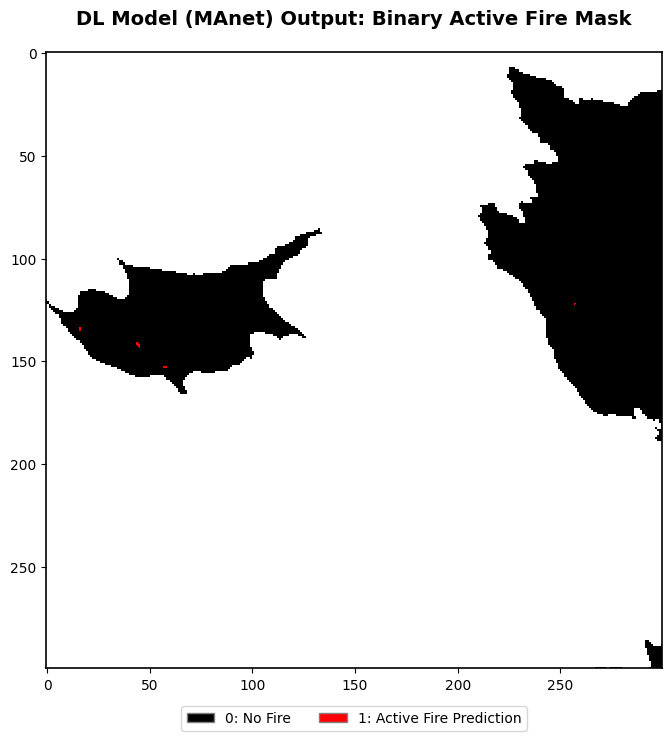

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

## Create a custom discrete colormap for binary data (0: Black, 1: Red)
custom_cmap = ListedColormap(['black', 'red'])

## Show the binary predicted fire pixels using the custom colormap
## Assuming the output array for the DL model is stored in the variable 'DL_image'
im = ax.imshow(DL_image, cmap=custom_cmap, vmin=0, vmax=1)

## Ensure plot aesthetics: remove grid lines and apply distinct bounding frame
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.2)

## Add title outside the image using the pad parameter
ax.set_title("DL Model (MAnet) Output: Binary Active Fire Mask", pad=20, fontsize=14, fontweight='bold')

## Create legend patches matching the custom colormap exactly
legend_labels = [
    mpatches.Patch(facecolor='black', edgecolor='gray', linewidth=1, label='0: No Fire'),
    mpatches.Patch(facecolor='red', edgecolor='gray', linewidth=1, label='1: Active Fire Prediction')
]

## Place the legend below the plot, centered, spreading across 2 columns
ax.legend(handles=legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.show()

## 5. Comparative Model Evaluation

This section generates a side-by-side visual comparison of the input Brightness Temperature data against the predictive outputs of both models. The three-panel layout displays the preprocessed MTG FCI Band 3.8 μm imagery, the Machine Learning (CatBoost) binary active fire mask, and the Deep Learning (MAnet) binary active fire mask. This comparative visualization allows for a direct spatial assessment of how each architecture maps thermal anomalies relative to the background context.

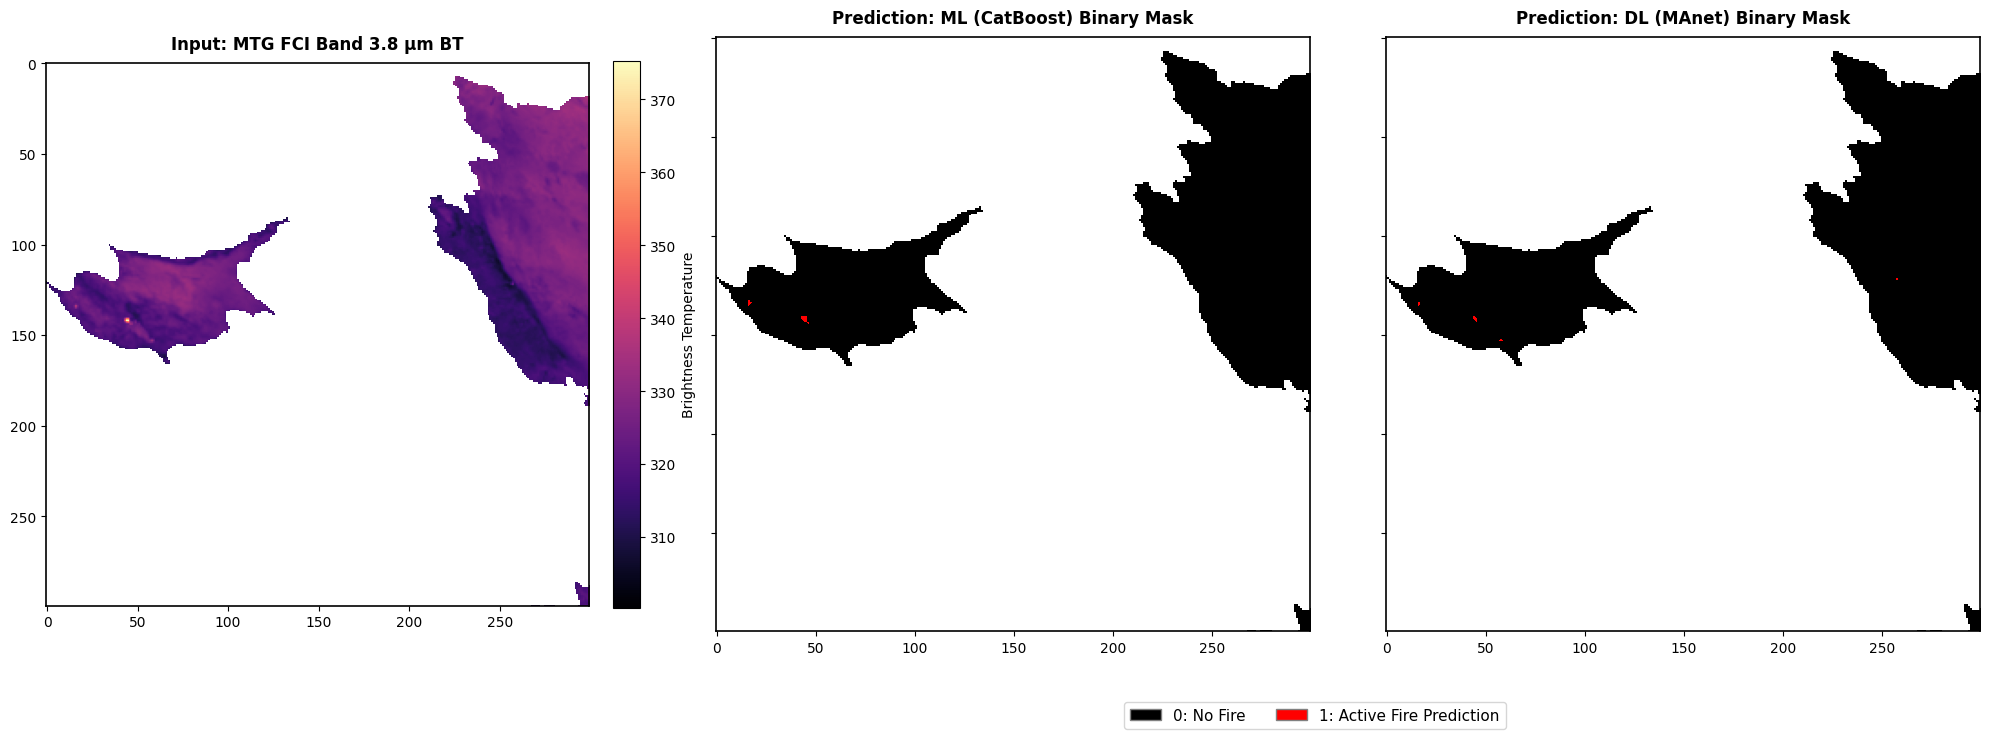

In [15]:
## Define a shared custom discrete colormap for the binary predictions (0: Black, 1: Red)
binary_cmap = ListedColormap(['black', 'red'])

## Initialize a 1-row, 3-column subplot figure
fig, ax = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

## ---------------- Panel 1: Brightness Temperature ----------------
## Extract values and ensure a 2D shape for standard imshow plotting
bt_img = cyprus[2].values.squeeze()
im0 = ax[0].imshow(bt_img, cmap='magma')
ax[0].set_title("Input: MTG FCI Band 3.8 μm BT", fontsize=12, fontweight='bold', pad=10)

## Add a continuous colorbar for the thermal values
cbar = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Brightness Temperature", fontsize=10)


## ---------------- Panel 2: ML Model (CatBoost) ----------------
## Ensure the ML image array is squeezed to 2D
ml_img = ML_image.squeeze()
im1 = ax[1].imshow(ml_img, cmap=binary_cmap, vmin=0, vmax=1)
ax[1].set_title("Prediction: ML (CatBoost) Binary Mask", fontsize=12, fontweight='bold', pad=10)


## ---------------- Panel 3: DL Model (MAnet) ----------------
## Ensure the DL image array is squeezed to 2D
dl_img = DL_image.squeeze()
im2 = ax[2].imshow(dl_img, cmap=binary_cmap, vmin=0, vmax=1)
ax[2].set_title("Prediction: DL (MAnet) Binary Mask", fontsize=12, fontweight='bold', pad=10)


## ---------------- Plot Aesthetics and Layout ----------------
## Apply consistent styling across all subplots
for a in ax:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.2)

## Define shared legend patches for the two binary prediction panels
legend_labels = [
    mpatches.Patch(facecolor='black', edgecolor='gray', linewidth=1, label='0: No Fire'),
    mpatches.Patch(facecolor='red', edgecolor='gray', linewidth=1, label='1: Active Fire Prediction')
]

## Place a single shared legend for the binary masks below panels 2 and 3
fig.legend(handles=legend_labels, loc='upper center', bbox_to_anchor=(0.66, 0.05), ncol=2, fontsize=11)

plt.tight_layout()
plt.show()